# Displaying results

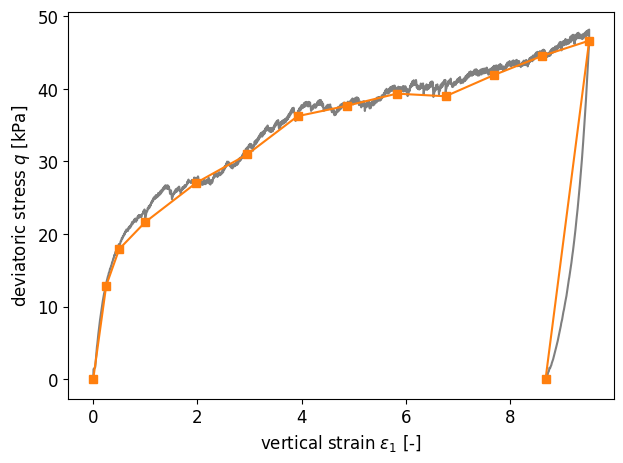

In [1]:
# plot macroscopic response of the DEM simulation

import numpy
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams.update({'font.size': 12})

folderExp = "dem_data/monotonic/maroscopic_response/"
data_dem = numpy.loadtxt(folderExp+"triax.plot-data.txt",skiprows=1,delimiter="\t")
data_steps = numpy.loadtxt(folderExp+"triax.state.txt",skiprows=1,delimiter=" ")

fig, ax = plt.subplots()
ax.plot(-1*data_dem[:,5]*100, -1*data_dem[:,11]/1000, '-', color='tab:grey', label='')
ax.plot(-1*data_steps[:,6]*100, -1*(data_steps[:,3]-data_steps[:,1])/1000, '-s', color='tab:orange', label='Stages')
ax.set_xlabel(r'vertical strain $\epsilon_1$ [-]')
ax.set_ylabel(r'deviatoric stress $q$ [kPa]')
plt.tight_layout()
plt.show()

In [2]:
import tifffile
import imageio.v2 as imageio
import numpy as np
import os
from skimage.transform import resize
from IPython.display import Image as uwu



# === CONFIGURATION ===
output_gif = "images/results/triax.0_slices.gif"
fps = 10                 # frames per second
normalize = True         # normalize intensities to 0–255
min_size = 500           # minimum width/height in pixels

if not os.path.exists("images/results") :
    os.makedirs("images/results")

def build_gif(input_tif) :
    # === LOAD TIFF ===
    # Check if path exists
    if not os.path.exists(input_tif) :
        print(f"No such file: {input_tif}")
        return
    volume = tifffile.imread(input_tif)  # shape = (z, y, x)
    
    # === NORMALIZE (optional) ===
    if normalize:
        vmin, vmax = np.percentile(volume, [0.5, 99.5])
        volume = np.clip((volume - vmin) / (vmax - vmin) * 255, 0, 255).astype(np.uint8)
    
    # === DETERMINE UPSCALE FACTOR ===
    h, w = volume.shape[1], volume.shape[2]
    scale = max(min_size / h, min_size / w, 1.0)  # only upscale, never downscale
    new_h, new_w = int(h * scale), int(w * scale)
    
    # === BUILD FRAME LIST ===
    frames = []
    for z in range(volume.shape[0]):
        frame = volume[z, :, :]
        if scale > 1.0:
            frame = resize(frame, (new_h, new_w), order=1, preserve_range=True).astype(np.uint8)
        frames.append(frame)
    
    # === SAVE GIF ===
    imageio.mimsave(output_gif, frames, fps=fps, loop=0)
    print(f"Displaying {input_tif}")
    display(uwu(filename=output_gif))

In [ ]:
input_tif = "./data_yukiko/images/default/triax.0.eps=-0.0025.spheres_image_gaussian=08_noise=03.tif"
#build_gif(input_tif)
input_tif = "images/truth/heightmap.tif"
build_gif(input_tif)